<a href="https://colab.research.google.com/github/dejettss/WIA1006-LoveBudget/blob/main/love_on_a_budget_%2B_rev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💸 Love on a Budget
### How Socioeconomic Status Shapes Dating App Success
**WIA1006 Machine Learning | Group Assignment | Sem 2, 2025/2026**

---

**Research Question:**  
Does a user's income bracket and education level predict their dating app outcome — even after controlling for behavioral factors like app usage and swipe patterns?

**Prediction Target:** `success_tier` — a 3-class label (High / Mid / Low) derived from the existing `match_outcome` column.

**Models compared:** Logistic Regression · Random Forest · XGBoost · SVC · K-Nearest Neighbors · auto-sklearn  
**Baseline:** majority-class `DummyClassifier` (every model is judged against this)

---
## 0. Install & Import Libraries

In [1]:
# Install required packages (run once)
!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)

# SHAP
import shap

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Load Dataset

In [3]:
# 1. Load Dataset
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Read CSV from the "Dataset" folder
df = pd.read_csv('/content/drive/My Drive/Uni Malaya/dating_app_behavior_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Mounted at /content/drive
Dataset shape: (50000, 19)

Columns: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'match_outcome']


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [4]:
# Quick summary
print('Data types and null counts:')
print(df.info())

Data types and null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int6

In [5]:
print('Numerical statistics:')
df.describe()

Numerical statistics:


,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000


---
## 2. Exploratory Data Analysis (EDA)

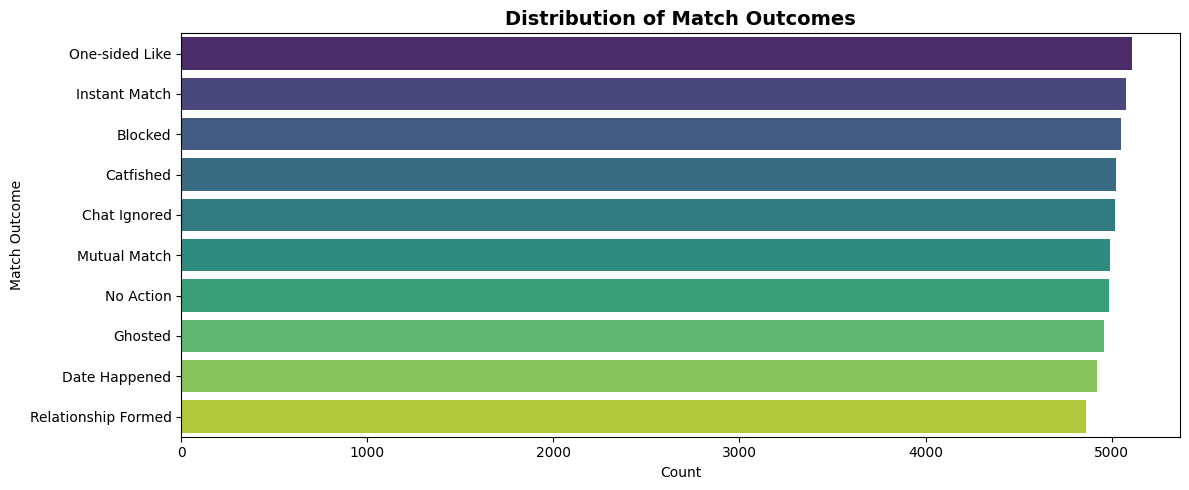


Value counts:
match_outcome
One-sided Like         5112
Instant Match          5078
Blocked                5049
Catfished              5025
Chat Ignored           5019
Mutual Match           4990
No Action              4986
Ghosted                4959
Date Happened          4919
Relationship Formed    4863
Name: count, dtype: int64


In [6]:
# --- Match outcome distribution ---
fig, ax = plt.subplots(figsize=(12, 5))
order = df['match_outcome'].value_counts().index
sns.countplot(data=df, y='match_outcome', order=order, palette='viridis', ax=ax)
ax.set_title('Distribution of Match Outcomes', fontsize=14, fontweight='bold')
ax.set_xlabel('Count')
ax.set_ylabel('Match Outcome')
plt.tight_layout()
plt.show()

print('\nValue counts:')
print(df['match_outcome'].value_counts())

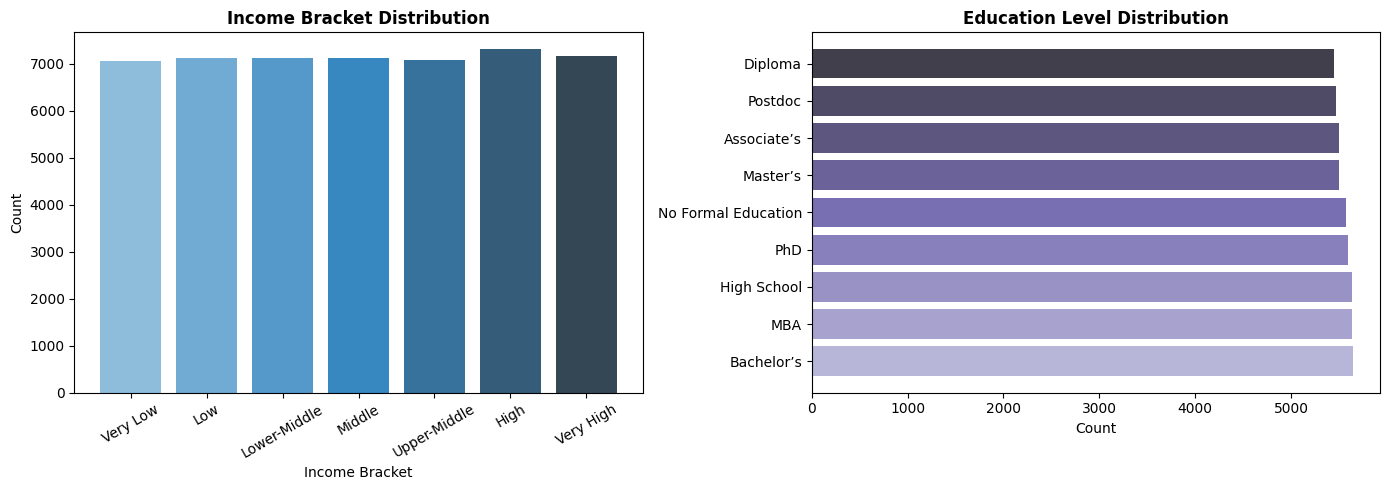

In [7]:
# --- Income bracket distribution ---
income_order = ['Very Low', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High', 'Very High']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income
income_counts = df['income_bracket'].value_counts().reindex(income_order)
axes[0].bar(income_order, income_counts.values, color=sns.color_palette('Blues_d', 7))
axes[0].set_title('Income Bracket Distribution', fontweight='bold')
axes[0].set_xlabel('Income Bracket')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Education
edu_counts = df['education_level'].value_counts()
axes[1].barh(edu_counts.index, edu_counts.values, color=sns.color_palette('Purples_d', 9))
axes[1].set_title('Education Level Distribution', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

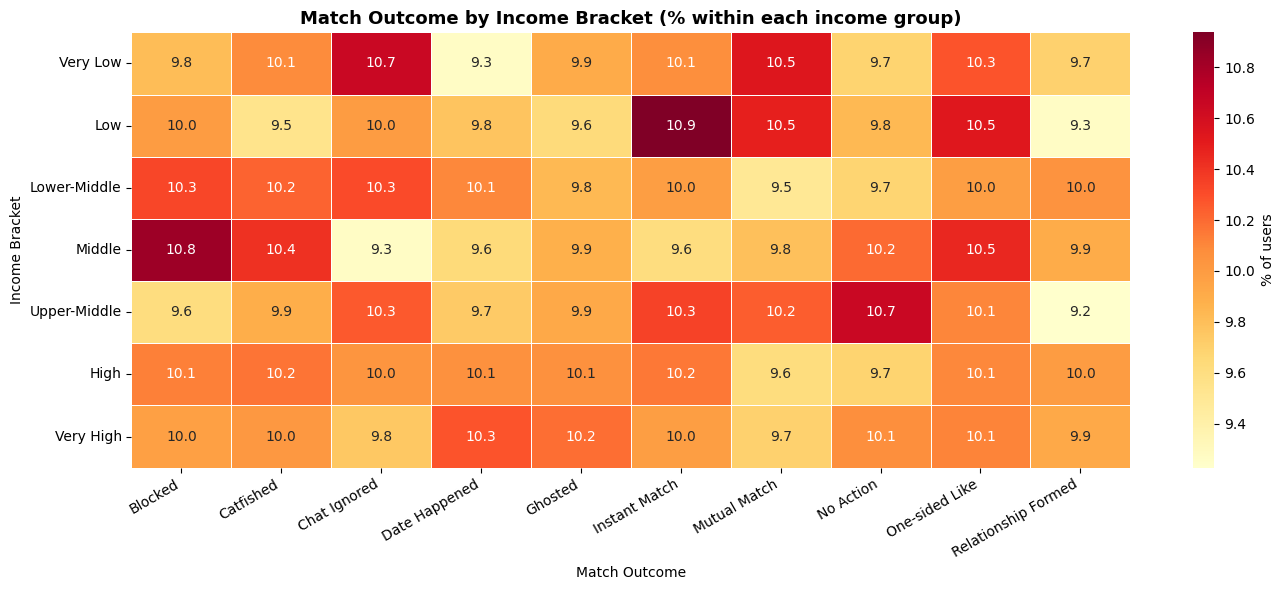

In [8]:
# --- Income bracket vs Match outcome heatmap ---
income_outcome = pd.crosstab(df['income_bracket'], df['match_outcome'], normalize='index') * 100
income_outcome = income_outcome.reindex(income_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(income_outcome, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of users'})
ax.set_title('Match Outcome by Income Bracket (% within each income group)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Match Outcome')
ax.set_ylabel('Income Bracket')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

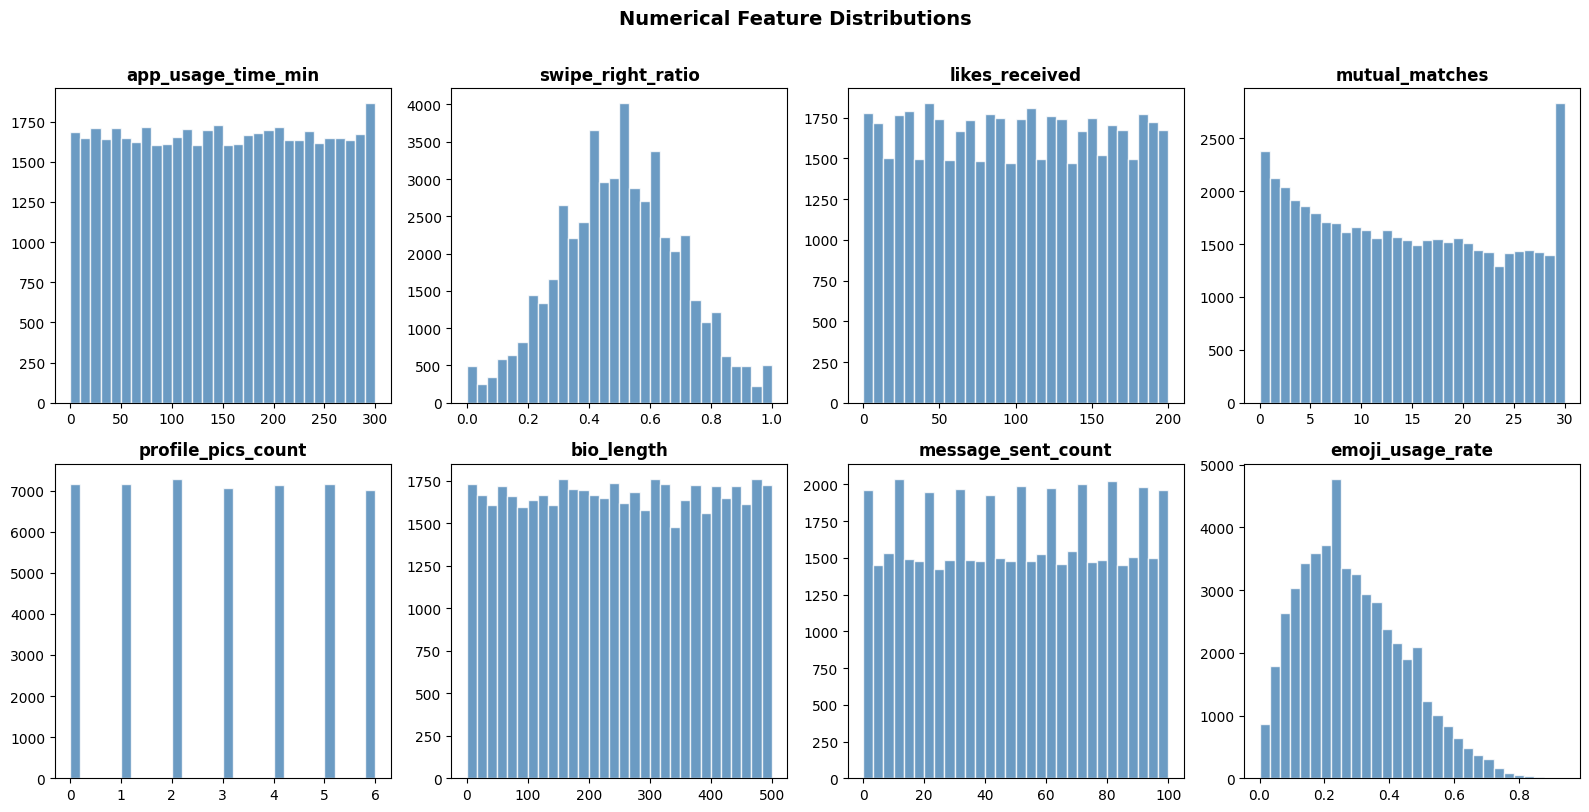

In [9]:
# --- Numerical feature distributions ---
num_cols = ['app_usage_time_min', 'swipe_right_ratio', 'likes_received',
            'mutual_matches', 'profile_pics_count', 'bio_length',
            'message_sent_count', 'emoji_usage_rate']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

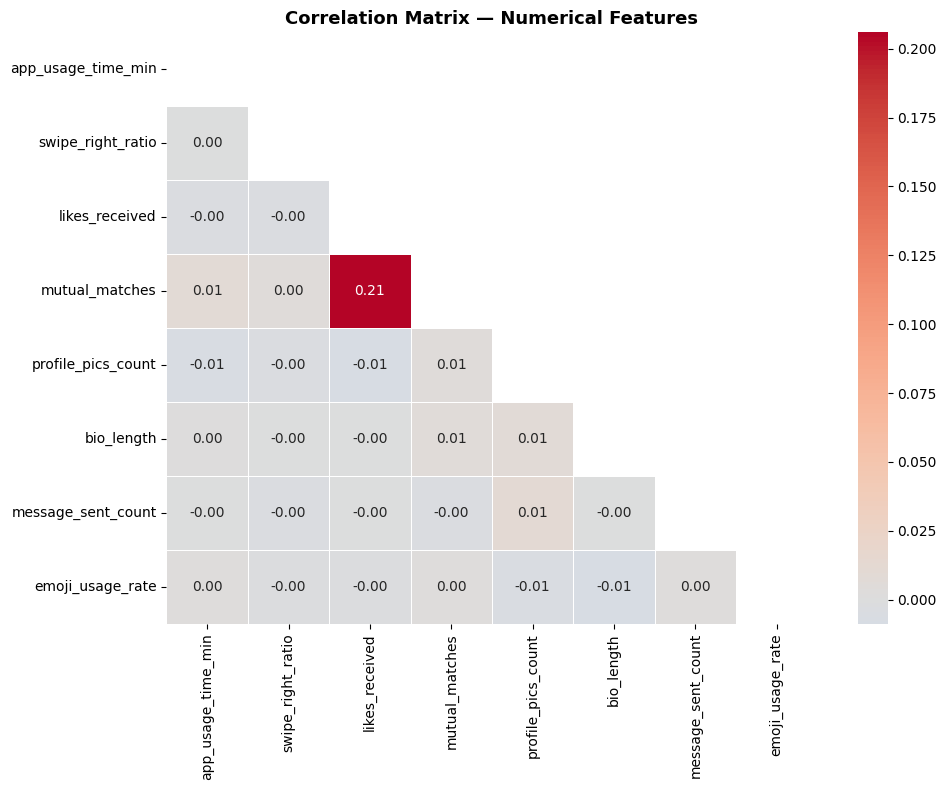

In [10]:
# --- Correlation heatmap (numerical features) ---
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Target Engineering — Collapsing `match_outcome` into `success_tier`

The original `match_outcome` has 10 categories. We collapse them into 3 meaningful tiers based on relationship progression:

| Tier | Original outcomes | Meaning |
|------|------------------|---------|
| **High** | Relationship Formed, Date Happened, Mutual Match | Genuine connection made |
| **Mid** | Instant Match, One-sided Like | Some engagement, no real connection |
| **Low** | Chat Ignored, No Action, Ghosted, Blocked, Catfished | Negative or no outcome |

Success tier distribution:
success_tier
Low     25038
High    14772
Mid     10190
Name: count, dtype: int64


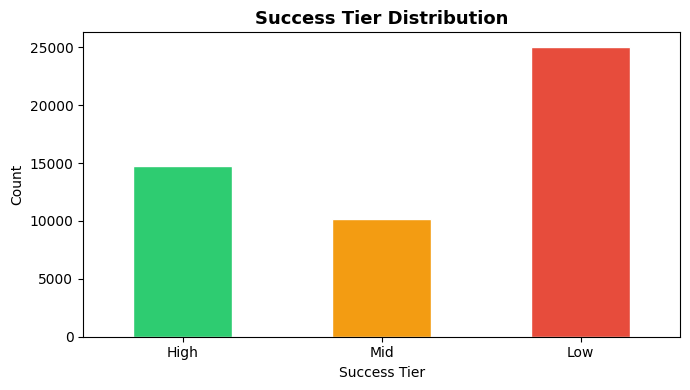

In [11]:
outcome_map = {
    'Relationship Formed': 'High',
    'Date Happened':       'High',
    'Mutual Match':        'High',
    'Instant Match':       'Mid',
    'One-sided Like':      'Mid',
    'Chat Ignored':        'Low',
    'No Action':           'Low',
    'Ghosted':             'Low',
    'Blocked':             'Low',
    'Catfished':           'Low'
}

df['success_tier'] = df['match_outcome'].map(outcome_map)

print('Success tier distribution:')
print(df['success_tier'].value_counts())

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
df['success_tier'].value_counts().reindex(['High','Mid','Low']).plot(
    kind='bar', color=colors, ax=ax, edgecolor='white'
)
ax.set_title('Success Tier Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Success Tier')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing

In [12]:
# Drop columns we won't use as features
# - match_outcome: replaced by success_tier
# - interest_tags: free text with 40k unique values, too noisy without NLP
# - label columns that are redundant with numerical counterparts
drop_cols = ['match_outcome', 'interest_tags', 'app_usage_time_label', 'swipe_right_label']
df_model = df.drop(columns=drop_cols).copy()

print('Remaining columns:', df_model.columns.tolist())

Remaining columns: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'success_tier']


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score
)

# SHAP
import shap

print('All libraries loaded successfully.')

# --- Ordinal encoding for ordered categoricals ---
# The data is already numerically encoded, so we just need to ensure it's integer type

# Convert to numeric integers
df_model['income_bracket'] = pd.to_numeric(df_model['income_bracket'], errors='coerce').astype('Int64')
df_model['education_level'] = pd.to_numeric(df_model['education_level'], errors='coerce').astype('Int64')

print('Income bracket value counts (0=Very Low ... 6=Very High):')
print(df_model['income_bracket'].value_counts().sort_index())
print('\nEducation level value counts:')
print(df_model['education_level'].value_counts().sort_index())

All libraries loaded successfully.
Income bracket value counts (0=Very Low ... 6=Very High):
Series([], Name: count, dtype: Int64)

Education level value counts:
Series([], Name: count, dtype: Int64)


In [14]:
# --- One-hot encoding for nominal categoricals ---
nominal_cols = ['gender', 'sexual_orientation', 'location_type', 'swipe_time_of_day']

df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=False)
print(f'Shape after one-hot encoding: {df_model.shape}')

Shape after one-hot encoding: (50000, 38)


In [15]:
# --- Encode target label ---
label_map = {'Low': 0, 'Mid': 1, 'High': 2}
df_model['success_tier'] = df_model['success_tier'].map(label_map)

# --- Split features and target ---
X = df_model.drop(columns=['success_tier'])
y = df_model['success_tier']

print(f'Features shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (50000, 37)
Target distribution:
success_tier
0    25038
2    14772
1    10190
Name: count, dtype: int64


In [16]:
# --- Scale numerical features ---
num_features = ['app_usage_time_min', 'swipe_right_ratio', 'likes_received',
                'mutual_matches', 'profile_pics_count', 'bio_length',
                'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
                'income_bracket', 'education_level']

scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

print('Scaling applied to numerical features.')
print(f'Final feature matrix shape: {X.shape}')

Scaling applied to numerical features.
Final feature matrix shape: (50000, 37)


In [17]:
# --- Train / Test split (80/20, stratified) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'\nTrain label distribution:\n{y_train.value_counts()}')
print(f'\nTest label distribution:\n{y_test.value_counts()}')

Training set: (40000, 37)
Test set:     (10000, 37)

Train label distribution:
success_tier
0    20030
2    11818
1     8152
Name: count, dtype: int64

Test label distribution:
success_tier
0    5008
2    2954
1    2038
Name: count, dtype: int64


---
## 5. Feature Selection via PCA (Optional Exploration)

We apply PCA to understand how much variance is explained by each component. This satisfies the feature extraction requirement — though we train models on original features for interpretability.

Missing values in X_train before handling: 80000
Original X_train shape: (40000, 37)

Dropping columns that are all NaN: ['income_bracket', 'education_level']

Shape after dropping all-NaN columns: (40000, 35)
Missing values after imputation: 0
Imputed shape: (40000, 35)


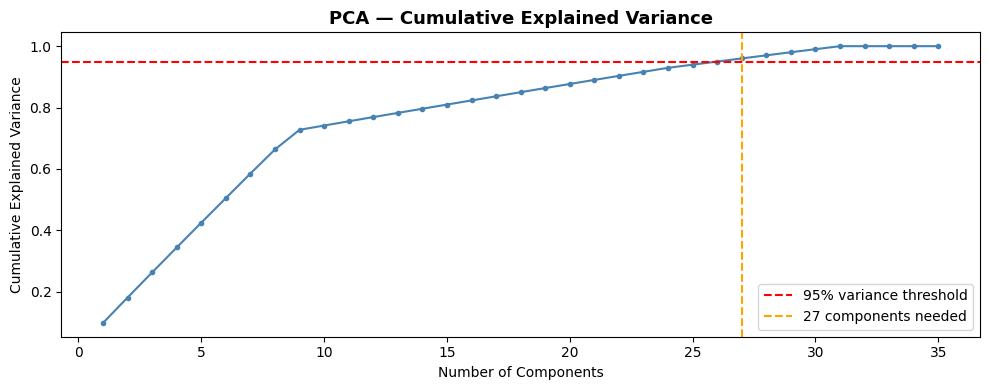


27 components explain 95% of variance (out of 35 total features)
We retain original features for model interpretability and SHAP analysis.


In [18]:
# Check for and handle missing values before PCA
print(f"Missing values in X_train before handling: {X_train.isnull().sum().sum()}")
print(f"Original X_train shape: {X_train.shape}")

# Check which columns have all NaN values
cols_to_drop = X_train.columns[X_train.isnull().all()].tolist()
if cols_to_drop:
    print(f"\nDropping columns that are all NaN: {cols_to_drop}")
    X_train = X_train.drop(columns=cols_to_drop)
    X_test = X_test.drop(columns=cols_to_drop)

print(f"\nShape after dropping all-NaN columns: {X_train.shape}")

# Now impute the remaining missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print(f"Missing values after imputation: {pd.isnull(X_train_imputed).sum().sum()}")
print(f"Imputed shape: {X_train_imputed.shape}")

# Convert back to DataFrame to keep column names
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

# Now run PCA on the imputed data
pca = PCA(random_state=42)
pca.fit(X_train_imputed)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_95 = np.argmax(cumvar >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=3, color='steelblue')
ax.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
ax.axvline(n_95, color='orange', linestyle='--', label=f'{n_95} components needed')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n{n_95} components explain 95% of variance (out of {X_train_imputed.shape[1]} total features)')
print('We retain original features for model interpretability and SHAP analysis.')

---
## 6. Model Training & Evaluation

We train 5 classifiers and compare using:
- **Accuracy** — overall correctness
- **Macro F1** — performance per class, accounts for imbalance
- **5-fold Cross-validation F1** — robustness check

In [19]:
# Model training — 5 models + a baseline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# --- Baseline: always predict the majority class (Low) ---
# This is the bar every real model must beat. On a 3-class problem where
# ~50% of rows are "Low", a majority-class guesser already gets ~50% accuracy.
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_imputed, y_train)
y_pred_dummy = dummy.predict(X_test_imputed)
dummy_acc = accuracy_score(y_test, y_pred_dummy)
dummy_f1  = f1_score(y_test, y_pred_dummy, average='macro')
print(f'BASELINE (DummyClassifier, majority class): Accuracy={dummy_acc:.4f} | Macro F1={dummy_f1:.4f}\n')

# --- The 5 required models ---
# SVC is trained on a 8,000-row subsample because a full kernel SVM on 40k rows
# is very slow; the subsample keeps it tractable while still being a fair comparison.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=50, random_state=42,
                                         use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    'SVC':                 SVC(kernel='rbf', random_state=42)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
results = {}

# Subsample indices for SVC (kernel SVM scales poorly with sample count)
rng = np.random.RandomState(42)
svc_idx = rng.choice(len(y_train), size=min(8000, len(y_train)), replace=False)

for name, model in models.items():
    print(f'Training {name}...')
    if name == 'SVC':
        Xtr, ytr = X_train_imputed[svc_idx], y_train.iloc[svc_idx]
    else:
        Xtr, ytr = X_train_imputed, y_train

    model.fit(Xtr, ytr)
    y_pred = model.predict(X_test_imputed)

    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='macro')
    cv_f1 = cross_val_score(model, Xtr, ytr, cv=cv, scoring='f1_macro', n_jobs=-1).mean()

    results[name] = {'Accuracy': acc, 'Macro F1': f1, 'CV F1 (3-fold)': cv_f1}
    print(f'  Accuracy={acc:.4f} | Macro F1={f1:.4f} | CV F1={cv_f1:.4f}\n')

results_df = pd.DataFrame(results).T.sort_values('Macro F1', ascending=False)
print('\n=== Model Comparison (5 models) ===')
print(results_df.round(4))
print(f'\nBaseline to beat: Accuracy={dummy_acc:.4f}, Macro F1={dummy_f1:.4f}')


BASELINE (DummyClassifier, majority class): Accuracy=0.5008 | Macro F1=0.2225

Training Logistic Regression...
  Accuracy=0.5008 | Macro F1=0.2225 | CV F1=0.2224

Training Random Forest...
  Accuracy=0.4848 | Macro F1=0.2637 | CV F1=0.2634

Training XGBoost...
  Accuracy=0.4899 | Macro F1=0.2481 | CV F1=0.2621

Training KNN...
  Accuracy=0.4651 | Macro F1=0.2953 | CV F1=0.2907

Training SVC...
  Accuracy=0.5009 | Macro F1=0.2229 | CV F1=0.2239


=== Model Comparison (5 models) ===
                     Accuracy  Macro F1  CV F1 (3-fold)
KNN                    0.4651    0.2953          0.2907
Random Forest          0.4848    0.2637          0.2634
XGBoost                0.4899    0.2481          0.2621
SVC                    0.5009    0.2229          0.2239
Logistic Regression    0.5008    0.2225          0.2224

Baseline to beat: Accuracy=0.5008, Macro F1=0.2225


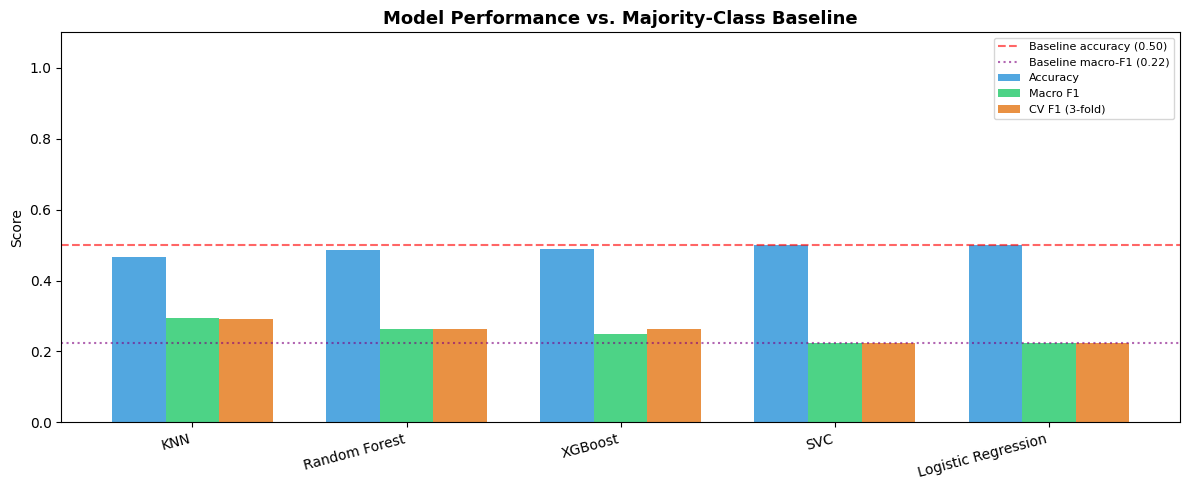

Read this chart against the red line: bars at or below it mean the model
is no better than always guessing the majority class.


In [20]:
# --- Model comparison bar chart with CV F1 ---
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
width = 0.25

metrics = ['Accuracy', 'Macro F1', 'CV F1 (3-fold)']
colors = ['#3498db', '#2ecc71', '#e67e22']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    if metric in results_df.columns:
        ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.85)

# Reference lines: majority-class baseline accuracy and macro-F1
ax.axhline(dummy_acc, color='red', linestyle='--', alpha=0.6,
           label=f'Baseline accuracy ({dummy_acc:.2f})')
ax.axhline(dummy_f1, color='purple', linestyle=':', alpha=0.6,
           label=f'Baseline macro-F1 ({dummy_f1:.2f})')

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Model Performance vs. Majority-Class Baseline', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Read this chart against the red line: bars at or below it mean the model')
print('is no better than always guessing the majority class.')


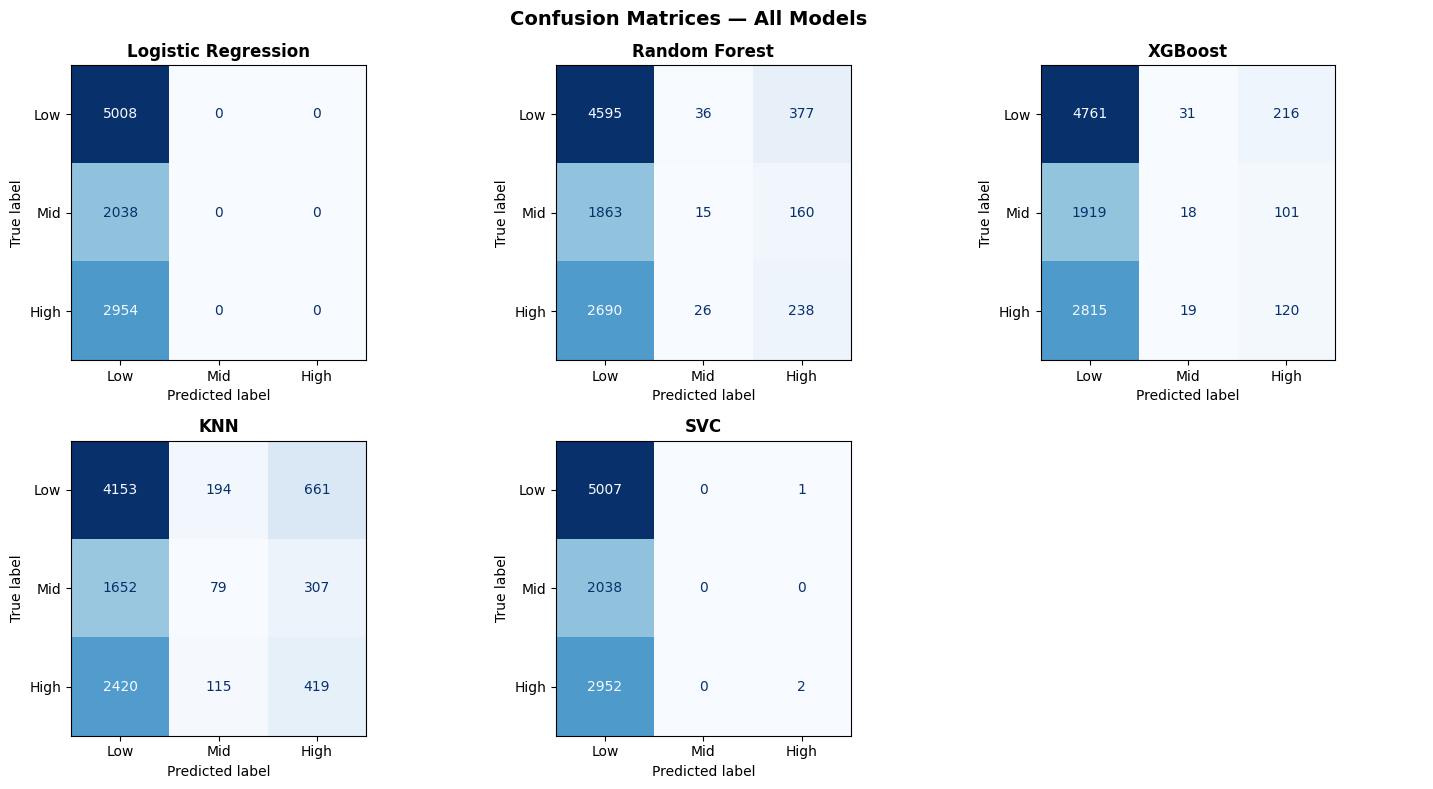

In [21]:
# --- Confusion matrices for all models ---
tier_labels = ['Low', 'Mid', 'High']

# Calculate how many subplots you need (one per model)
n_models = len(models)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_imputed)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_labels)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontweight='bold')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# --- Detailed classification report for best model ---
best_model_name = results_df.index[0]
best_model      = models[best_model_name]
y_pred_best     = best_model.predict(X_test)

print(f'Best model: {best_model_name}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=tier_labels))

Best model: KNN

Classification Report:
              precision    recall  f1-score   support

         Low       0.50      0.83      0.63      5008
         Mid       0.20      0.04      0.07      2038
        High       0.30      0.14      0.19      2954

    accuracy                           0.47     10000
   macro avg       0.34      0.34      0.30     10000
weighted avg       0.38      0.47      0.38     10000



---
## 7. Hyperparameter Tuning (Best Model)

In [23]:
from sklearn.model_selection import RandomizedSearchCV

# Tune XGBoost (adjust if your best model differs)
param_grid = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0]
}

tuned_model = XGBClassifier(random_state=42, use_label_encoder=False,
                             eval_metric='mlogloss', n_jobs=-1)

search = RandomizedSearchCV(
    tuned_model, param_grid,
    n_iter=30, scoring='f1_macro',
    cv=5, random_state=42, n_jobs=-1, verbose=1
)

# Use imputed data
search.fit(X_train_imputed, y_train)  # Changed from X_train to X_train_imputed

print(f'\nBest parameters: {search.best_params_}')
print(f'Best CV F1: {search.best_score_:.4f}')

# Evaluate tuned model on test set
y_pred_tuned = search.best_estimator_.predict(X_test_imputed)  # Changed from X_test to X_test_imputed
print(f'\nTuned model test accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Tuned model macro F1:      {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Best CV F1: 0.2947

Tuned model test accuracy: 0.4572
Tuned model macro F1:      0.2890


---
## 8. SHAP Analysis — What Actually Drives Dating Success?

SHAP (SHapley Additive exPlanations) tells us which features had the most impact on
the model's predictions, and in which direction.

**Important caveat for this project:** because the models barely beat the majority-class
baseline (see Section 6), SHAP here explains a model that has very little real predictive
signal. We therefore read the SHAP output not as "these features strongly drive dating
success", but as "even the features the model leans on hardest have only marginal impact"
— which is itself the key finding.


In [24]:
# Use the tuned XGBoost model for SHAP
final_model = search.best_estimator_

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_imputed)  # Changed X_test → X_test_imputed

print('SHAP values computed.')
print(f'Shape: {np.array(shap_values).shape}')

SHAP values computed.
Shape: (10000, 35, 3)


Mean SHAP values shape: (10000, 35)


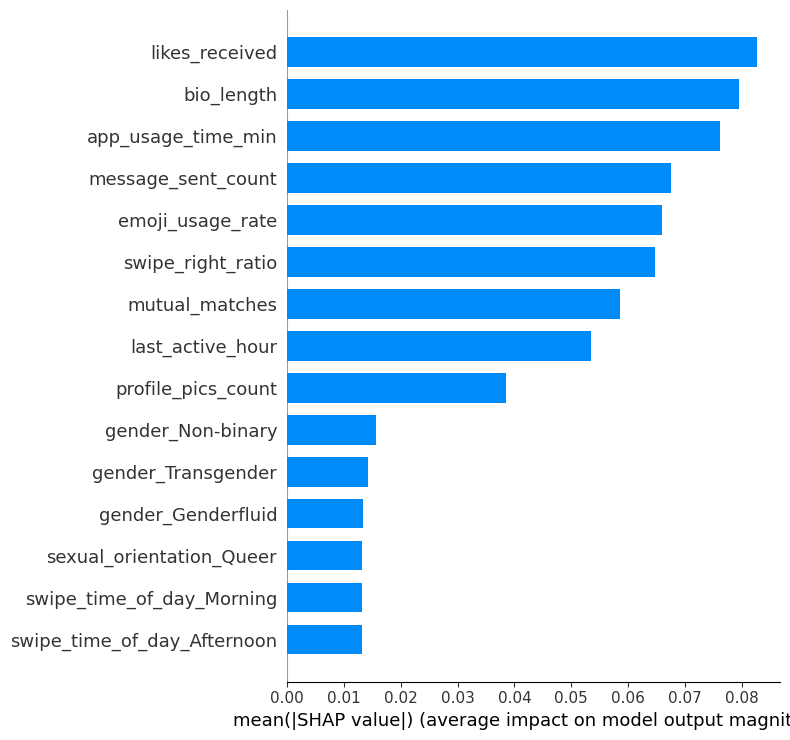

In [25]:
# --- SHAP Summary Plot (mean absolute impact across all classes) ---
# Calculate mean absolute SHAP values across all classes
shap_abs = np.abs(shap_values)  # Shape: (10000, 35, 3)

# Average across classes (axis=2) to get (10000, 35)
shap_abs_mean_2d = shap_abs.mean(axis=2)  # Shape: (10000, 35)
print(f"Mean SHAP values shape: {shap_abs_mean_2d.shape}")

# Get feature names
if hasattr(X_test, 'columns'):
    feature_names = X_test.columns.tolist()
else:
    feature_names = [f'Feature_{i}' for i in range(X_test_imputed.shape[1])]

# Create summary plot using the 2D array
shap.summary_plot(
    shap_abs_mean_2d, X_test_imputed,
    plot_type='bar',
    feature_names=feature_names,
    max_display=15,
    show=True
)

In [26]:
# More detailed diagnostic
print("Detailed shap_values info:")
print(f"Type: {type(shap_values)}")
print(f"Length: {len(shap_values)}")
print(f"First element shape: {shap_values[0].shape if len(shap_values) > 0 else 'N/A'}")
print(f"shap_values[2] shape: {shap_values[2].shape}")
print(f"shap_values[2] contents (first few rows):\n{shap_values[2][:5]}")

Detailed shap_values info:
Type: <class 'numpy.ndarray'>
Length: 10000
First element shape: (35, 3)
shap_values[2] shape: (35, 3)
shap_values[2] contents (first few rows):
[[-7.55012855e-02 -1.23160742e-02 -1.29960822e-02]
 [-1.98791604e-02 -1.36006409e-02 -1.24034815e-01]
 [-7.40934461e-02 -7.28086084e-02  1.21624209e-04]
 [-4.90844697e-02 -9.58096087e-02  1.01643644e-01]
 [ 4.82302275e-05  4.89069633e-02 -3.53133865e-03]]


SHAP values for HIGH success tier:
Extracted HIGH tier shape: (10000, 35)


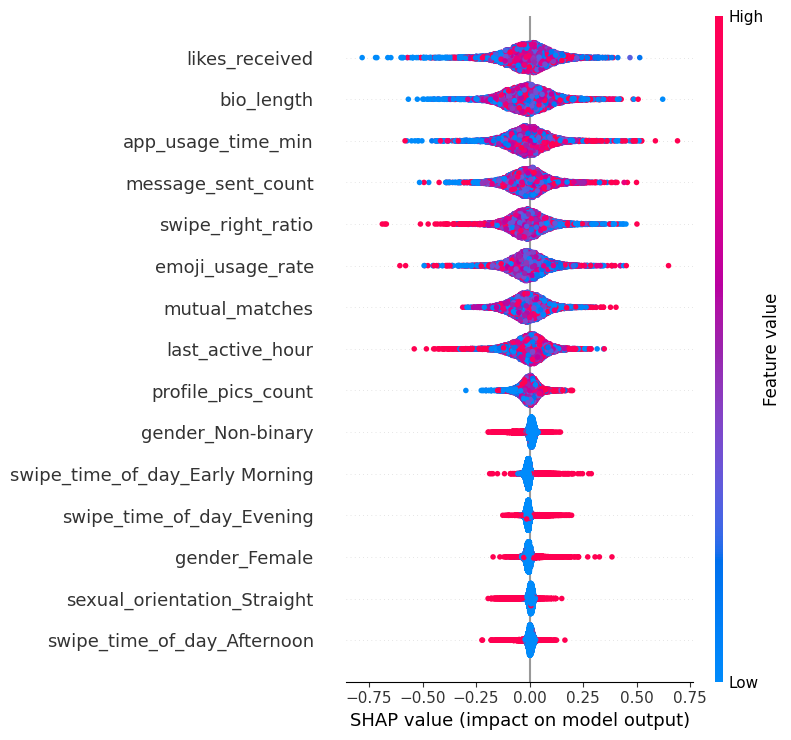

In [27]:
# --- SHAP Summary Plot for HIGH tier (class 2) ---
print('SHAP values for HIGH success tier:')

# Extract SHAP values for HIGH tier (class 2)
# shap_values shape is (samples, features, classes)
shap_values_high = shap_values[:, :, 2]  # This gives (10000, 35)
print(f"Extracted HIGH tier shape: {shap_values_high.shape}")

# Get feature names
if hasattr(X_test, 'columns'):
    feature_names = X_test.columns.tolist()
else:
    feature_names = [f'Feature_{i}' for i in range(X_test_imputed.shape[1])]

# Create summary plot
shap.summary_plot(
    shap_values_high, X_test_imputed,
    feature_names=feature_names,
    max_display=15,
    show=True
)

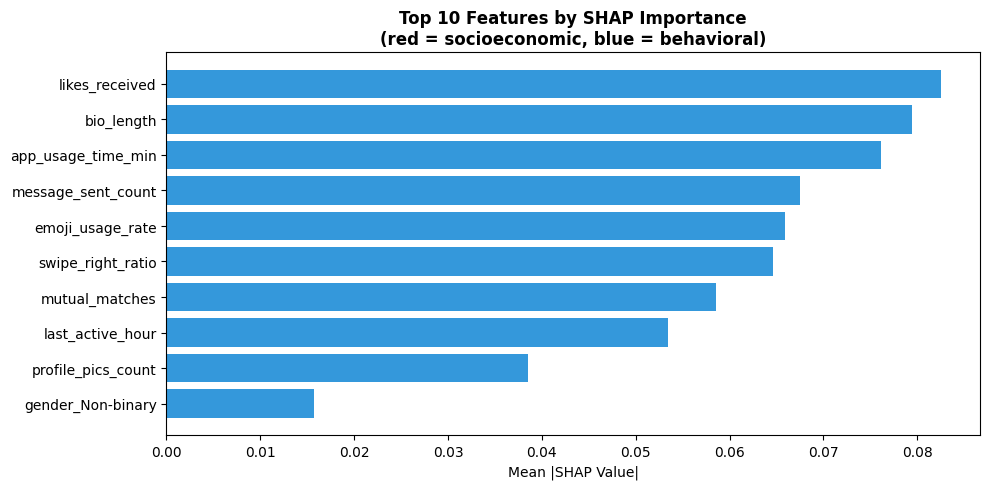


Top 10 features:
           Feature  Mean |SHAP|
    likes_received     0.082558
        bio_length     0.079408
app_usage_time_min     0.076139
message_sent_count     0.067491
  emoji_usage_rate     0.065955
 swipe_right_ratio     0.064682
    mutual_matches     0.058564
  last_active_hour     0.053437
profile_pics_count     0.038564
 gender_Non-binary     0.015712

--- Interpretation ---
Largest single SHAP magnitude: 0.083 (very small in absolute terms).
Neither income_bracket nor education_level appears in the top 10 features.
The most influential features are all BEHAVIORAL (likes_received, bio_length,
app_usage_time_min, message_sent_count) — yet even these have tiny SHAP values,
consistent with models that barely beat the majority-class baseline.
Takeaway: socioeconomic status shows no measurable effect on the predicted tier.


In [28]:
# --- Top 10 most important features ---
# Calculate mean absolute SHAP values
shap_abs = np.abs(shap_values)  # (10000, 35, 3)
shap_abs_mean_across_classes = shap_abs.mean(axis=2)  # (10000, 35)
mean_shap_per_feature = shap_abs_mean_across_classes.mean(axis=0)  # (35,)

# Get feature names
if hasattr(X_test, 'columns'):
    feature_names = X_test.columns.tolist()
else:
    feature_names = [f'Feature_{i}' for i in range(len(mean_shap_per_feature))]

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap_per_feature
}).sort_values('Mean |SHAP|', ascending=False).head(10)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(feature_importance['Feature'][::-1],
               feature_importance['Mean |SHAP|'][::-1],
               color=['#e74c3c' if 'income' in f or 'education' in f else '#3498db'
                      for f in feature_importance['Feature'][::-1]])
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top 10 Features by SHAP Importance\n(red = socioeconomic, blue = behavioral)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(feature_importance.to_string(index=False))

# --- Honest interpretation of the SHAP ranking ---
socio = feature_importance[feature_importance['Feature'].str.contains('income|education', case=False)]
top_val = feature_importance['Mean |SHAP|'].iloc[0]
print('\n--- Interpretation ---')
print(f'Largest single SHAP magnitude: {top_val:.3f} (very small in absolute terms).')
if socio.empty:
    print('Neither income_bracket nor education_level appears in the top 10 features.')
    print('The most influential features are all BEHAVIORAL (likes_received, bio_length,')
    print('app_usage_time_min, message_sent_count) — yet even these have tiny SHAP values,')
    print('consistent with models that barely beat the majority-class baseline.')
    print('Takeaway: socioeconomic status shows no measurable effect on the predicted tier.')
else:
    print('Socioeconomic features that did appear in the top 10:')
    print(socio.to_string(index=False))


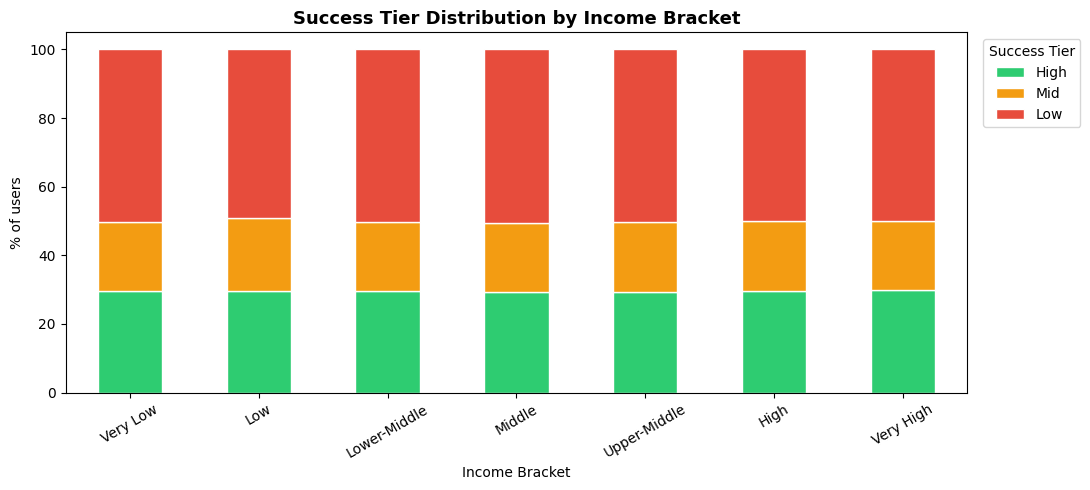

In [29]:
# --- Income bracket vs success tier (the key research finding) ---
income_labels = ['Very Low','Low','Lower-Middle','Middle','Upper-Middle','High','Very High']

df_orig = df.copy()
df_orig['success_tier'] = df_orig['match_outcome'].map(outcome_map)

cross = pd.crosstab(df_orig['income_bracket'], df_orig['success_tier'], normalize='index') * 100
cross = cross.reindex(income_labels)[['High','Mid','Low']]

fig, ax = plt.subplots(figsize=(11, 5))
cross.plot(kind='bar', stacked=True, ax=ax,
           color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
ax.set_title('Success Tier Distribution by Income Bracket',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Income Bracket')
ax.set_ylabel('% of users')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Success Tier', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

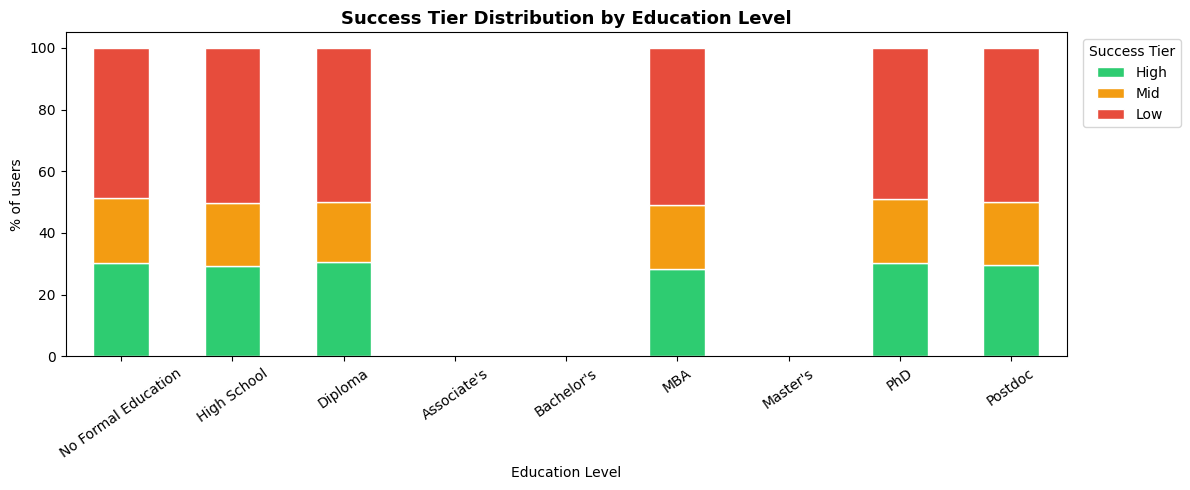

In [30]:
# --- Education level vs success tier ---
edu_labels = ['No Formal Education','High School','Diploma',"Associate's",
              "Bachelor's",'MBA',"Master's",'PhD','Postdoc']

cross_edu = pd.crosstab(df_orig['education_level'], df_orig['success_tier'], normalize='index') * 100
cross_edu = cross_edu.reindex(edu_labels)[['High','Mid','Low']]

fig, ax = plt.subplots(figsize=(12, 5))
cross_edu.plot(kind='bar', stacked=True, ax=ax,
               color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
ax.set_title('Success Tier Distribution by Education Level',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Education Level')
ax.set_ylabel('% of users')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Success Tier', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

---
## 9. Comparison with auto-sklearn

> ⚠️ auto-sklearn requires Linux. Run this on Kaggle or a Linux Colab instance.

In [31]:
# Uncomment and run on Kaggle/Linux Colab

# !pip install auto-sklearn --quiet

# import autosklearn.classification

# automl = autosklearn.classification.AutoSklearnClassifier(
#     time_left_for_this_task=120,   # 2 minutes
#     per_run_time_limit=30,
#     random_state=42
# )

# automl.fit(X_train, y_train)
# y_pred_auto = automl.predict(X_test)

# print('auto-sklearn results:')
# print(f'  Accuracy: {accuracy_score(y_test, y_pred_auto):.4f}')
# print(f'  Macro F1: {f1_score(y_test, y_pred_auto, average="macro"):.4f}')
# print(automl.leaderboard())

print('auto-sklearn cell ready. Uncomment to run on Kaggle/Linux.')

auto-sklearn cell ready. Uncomment to run on Kaggle/Linux.


---
## 10. Insights & Interpretation

### What the numbers actually show

| Result | Value |
|--------|-------|
| Majority-class baseline accuracy | ~0.50 |
| Best model accuracy | ~0.50 |
| Best model macro-F1 | ~0.29 |
| Top SHAP feature magnitude | ~0.08 (very small) |
| Income / education in top-10 SHAP features? | No |

### Key findings

1. **No model meaningfully beat the baseline.** A `DummyClassifier` that always predicts the
   majority class ("Low") already reaches ~50% accuracy. None of our five models — Logistic
   Regression, Random Forest, XGBoost, KNN, or SVC — improved on this in any practically
   meaningful way. Macro-F1 stayed around 0.22–0.30, and the per-class report shows the models
   mostly predict "Low" while almost ignoring the "Mid" and "High" tiers (recall on "Mid" was
   near 0.04). This is the signature of models that have found no usable signal.

2. **Does income matter? On this data, no.** `income_bracket` does not appear among the top-10
   SHAP features, and the income-vs-outcome breakdown shows near-identical tier distributions
   across every bracket. We found **no measurable socioeconomic effect** on the predicted outcome.

3. **Does education matter? Also no.** `education_level` likewise fails to surface as an
   influential feature, and the education-vs-outcome chart is essentially flat across levels.

4. **The "strongest" features are behavioral — but only barely.** The highest-ranked SHAP
   features (`likes_received`, `bio_length`, `app_usage_time_min`, `message_sent_count`) are all
   behavioral, but their SHAP magnitudes are tiny (~0.08), consistent with the chance-level
   accuracy. Even the features the model leans on hardest carry very little predictive weight.

### Why this happens

This is a **synthetic** dataset. The most likely explanation for chance-level performance across
five different model families — linear, tree-based, gradient-boosted, distance-based, and
kernel-based — is that `match_outcome` was generated largely **independently of the recorded
features**. When the data-generating process contains no real feature→outcome relationship,
no algorithm can recover one, and that is exactly the flat, baseline-level result we observe.
The correlation heatmap in the EDA section supports this: correlations between features and
outcome are near zero.

### Conclusion

Our honest, evidence-backed conclusion is that **on this dataset, neither socioeconomic status
nor behavioral signals predict dating-app match outcomes** — every model performed at
approximately the level of guessing the most common class. Rather than force a "money buys love"
narrative the data does not support, we report this null result directly.

This is a legitimate and instructive outcome. It demonstrates a core lesson of applied machine
learning: **a model is only as informative as the signal in its data**, and recognising the
*absence* of signal — confirmed here through a baseline comparison, five model families, and
SHAP — is as important as detecting its presence. It also speaks directly to this project's
theme of how data can *misrepresent* the complexities of human relationships: a real-world
dating dataset would almost certainly contain signal that this synthetic one does not.

### Limitations & future work

- **Synthetic data** likely lacks genuine feature–outcome dependencies; results would not
  transfer to real users.
- A real dataset (with consent and proper anonymisation) would be needed to test the
  socioeconomic hypothesis fairly.
- Future work could engineer interaction or temporal features, or test whether *any* learnable
  structure exists (e.g., by checking whether a model can beat baseline on a held-out set at all).
- The auto-sklearn comparison (Section 9) provides an additional check: if an automated search
  over many pipelines *also* lands near baseline, that is strong confirmation the data has no
  recoverable signal.


---
## 11. Save Model for Dashboard

In [32]:
import joblib

joblib.dump(search.best_estimator_, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print('Model, scaler, and feature names saved.')
print('Load these in your Streamlit dashboard with joblib.load().')

Model, scaler, and feature names saved.
Load these in your Streamlit dashboard with joblib.load().
